# Binary Classification using TensorFlow and Keras

## Objective

The objective of this project is to develop and train a deep learning model
for a binary classification task using TensorFlow and Keras.

The workflow includes:
- Exploratory Data Analysis (EDA)
- Data preprocessing
- Neural network architecture design
- Training using validation strategies (EarlyStopping & ModelCheckpoint)
- Final evaluation on unseen test data


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


## Dataset Description

The Breast Cancer dataset is loaded from Scikit-learn.
It contains 569 samples and 30 numerical features describing tumor characteristics.
The target variable is binary:
- 0 = Malignant
- 1 = Benign


In [3]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print("Dataset loaded successfully")
print("Shape of X:", X.shape)


Dataset loaded successfully
Shape of X: (569, 30)


## Initial Data Inspection

We inspect the dataset to understand:
- Number of samples
- Number of features
- Statistical properties
- Missing values


In [4]:
X.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
print("Target values:", y.unique())
print("Counts:\n", y.value_counts())


Target values: [0 1]
Counts:
 1    357
0    212
Name: count, dtype: int64


In [6]:
print("Total missing values:", X.isnull().sum().sum())


Total missing values: 0


In [7]:
X.describe()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


## Exploratory Data Analysis (EDA)

EDA helps in understanding:
- Class distribution
- Feature distribution
- Correlations between variables


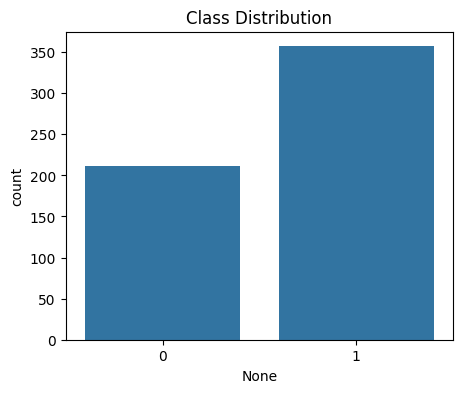

In [8]:
plt.figure(figsize=(5,4))
sns.countplot(x=y)
plt.title("Class Distribution")
plt.show()


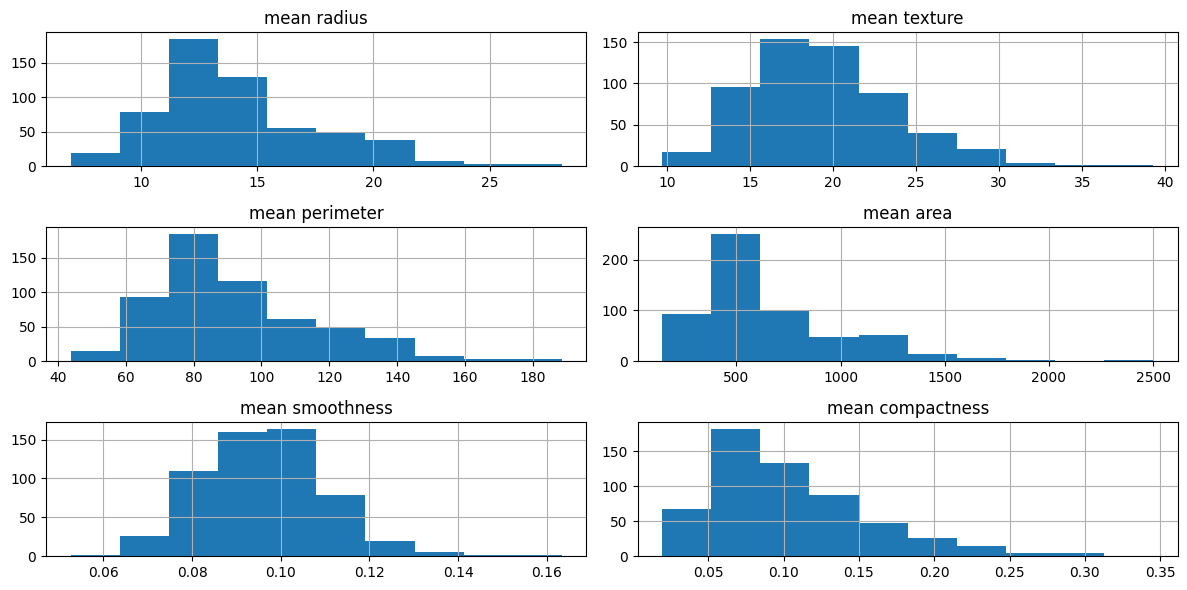

In [9]:
X.iloc[:, :6].hist(figsize=(12,6))
plt.tight_layout()
plt.show()


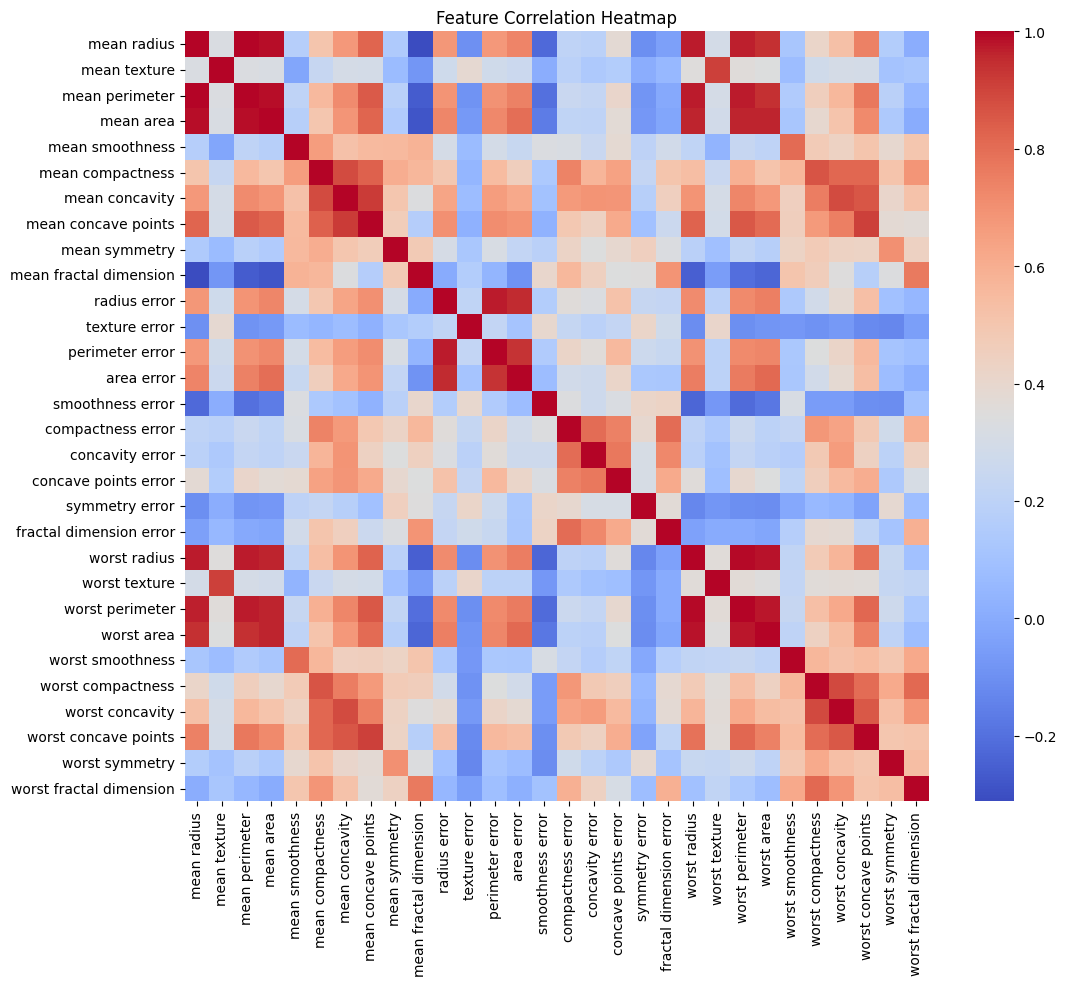

In [10]:
plt.figure(figsize=(12,10))
sns.heatmap(X.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


## Data Preprocessing

To ensure efficient neural network training:

- Features are scaled using StandardScaler
- Dataset is split into:
  - 60% Training
  - 20% Validation
  - 20% Test
- Stratified sampling is used to preserve class distribution


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaling completed")


Scaling completed


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled,
    y,
    test_size=0.4,
    random_state=42,
    stratify=y
)

print("First split done")


First split done


In [13]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Second split done")


Second split done


In [14]:
print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)


Train shape: (341, 30)
Validation shape: (114, 30)
Test shape: (114, 30)


## Neural Network Architecture

The model is built using the Sequential API.

Architecture:
- Input layer matching feature size
- Three hidden layers with ReLU activation
- Output layer with a single neuron and sigmoid activation

ReLU is used to introduce non-linearity.
Sigmoid is used to produce probability output for binary classification.


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

print("Model created successfully")


Model created successfully


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,337 (56.00 KB)

 Trainable params: 14,337 (56.00 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model compiled")


Model compiled


In [18]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)


In [19]:
checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_loss',
    save_best_only=True
)


## Model Training

The model is compiled using:

- Loss Function: Binary Crossentropy
- Optimizer: Adam
- Metric: Accuracy

Callbacks Used:
- EarlyStopping (to prevent overfitting)
- ModelCheckpoint (to save best model)


In [20]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[early_stop, checkpoint],
    verbose=1
)


Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.8974 - loss: 0.5474 - val_accuracy: 0.9561 - val_loss: 0.3468
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9473 - loss: 0.2831 - val_accuracy: 0.9649 - val_loss: 0.1681
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9368 - loss: 0.1822 - val_accuracy: 0.9649 - val_loss: 0.0922
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9507 - loss: 0.1028 - val_accuracy: 0.9737 - val_loss: 0.0675
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9877 - loss: 0.0592 - val_accuracy: 0.9737 - val_loss: 0.0574
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9841 - loss: 0.0517 - val_accuracy: 0.9737 - val_loss: 0.0541
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9867 - loss: 0.0566 - val_accuracy: 0.9737 - val_loss: 0.0501
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9917 - loss: 0.0338 - val_accuracy: 0.

In [21]:
y_prob = model.predict(X_test)
y_pred = (y_prob > 0.5).astype(int)

print("Predictions done")


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Predictions done


## Model Evaluation on Test Set

The final model is evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC Score
- Confusion Matrix
- ROC Curve


In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.95      0.98      0.97        43
           1       0.99      0.97      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [23]:
from sklearn.metrics import roc_auc_score

print("ROC-AUC:", roc_auc_score(y_test, y_prob))


ROC-AUC: 0.9954143465443825


## Training Performance Visualization

The following plots show:
- Training vs Validation Loss
- Training vs Validation Accuracy

These help in identifying overfitting or underfitting.


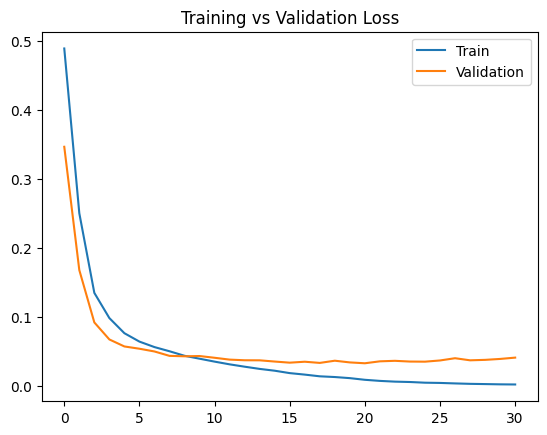

In [24]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train','Validation'])
plt.title("Training vs Validation Loss")
plt.show()


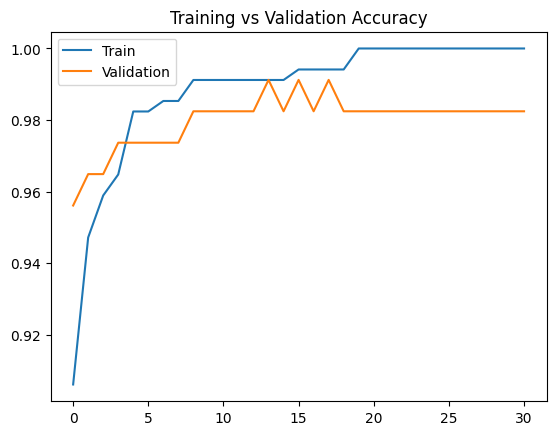

In [25]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.title("Training vs Validation Accuracy")
plt.show()


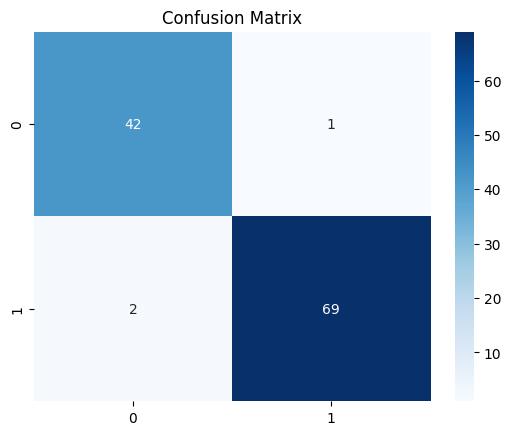

In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


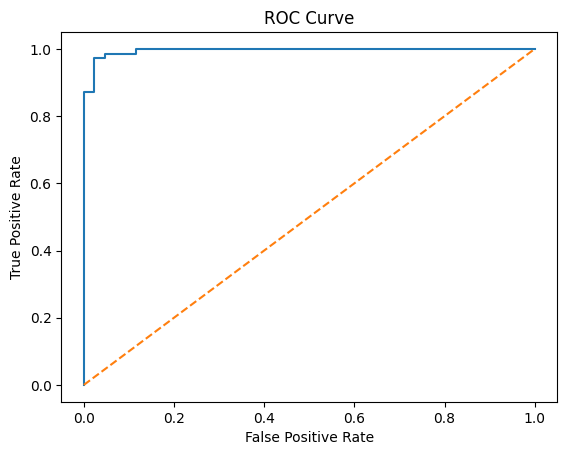

In [27]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()


In [28]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Final Test Accuracy:", test_acc)


Final Test Accuracy: 0.9736841917037964


## Conclusion

The deep learning model successfully learned the binary classification task.

EarlyStopping prevented overfitting while ModelCheckpoint ensured the best-performing model was saved.

The model achieved strong performance on the unseen test dataset,
with high F1-score and ROC-AUC values exceeding the required threshold.

This project demonstrates a complete and robust deep learning workflow.


## Future Improvements

- Hyperparameter tuning
- Adding dropout layers
- Testing alternative optimizers
- Applying cross-validation
